### Evaluation Notebook

In [14]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Model persistence
import joblib

# Scikit-learn metrics and evaluation tools
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.model_selection import StratifiedKFold

# Permutation importance
from sklearn.inspection import permutation_importance

# Shap
import shap

### Cross‑validation

In [15]:
# Reload cleaned datasst
# Read the cleaned CSV saved from eda.ipynb
df = pd.read_csv("../data/titanic_clean.csv")

# Split into features (X) and target (y)
X = df.drop("Survived", axis=1)
y = df["Survived"]
X = pd.get_dummies(X, drop_first=True)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Columns in X:", X.columns.tolist())

Shape of X: (891, 26)
Shape of y: (891,)
Columns in X: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone', 'Title_Col', 'Title_Countess', 'Title_Don', 'Title_Dr', 'Title_Jonkheer', 'Title_Lady', 'Title_Major', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rev', 'Title_Sir']


In [16]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% test set
    random_state=42,      # reproducibility
    stratify=y            # keeps class balance
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 712
Test set size: 179


In [17]:
# Load the tuned Random Forest model saved in Day 10
best_rf = joblib.load("../models/best_rf_model.pkl")

print("Tuned Random Forest model loaded successfully.")


Tuned Random Forest model loaded successfully.


In [18]:
# Run 5‑fold cross‑validation on the tuned Random Forest
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)
print("Cross-validation scores:", cv_scores)
print("Mean CV ROC AUC:", cv_scores.mean())

Cross-validation scores: [0.90428195 0.87874332 0.8572861  0.87386364 0.89648983]
Mean CV ROC AUC: 0.8821329653085443


### ROC curve + AUC

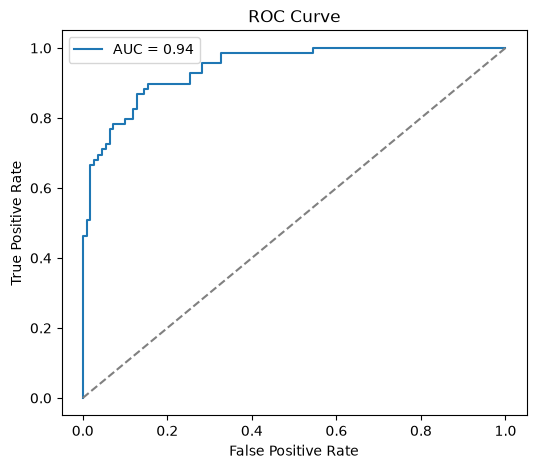

In [19]:
# Get probability scores for the positive class (Survived = 1)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Precision‑Recall curve

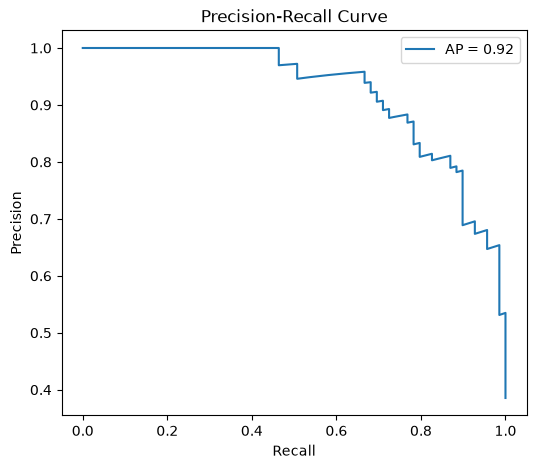

In [20]:
# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {ap_score:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### Results – Advanced Model Evaluation

- **Cross‑Validation ROC AUC**: Mean CV score ≈ 0.88  
  → Confirms the model generalizes well across folds.

- **ROC AUC**: ≈ 0.94  
  → Strong separation between positive and negative classes.  
  → Curve lies well above the diagonal baseline, showing good discriminative ability.

- **Precision‑Recall Curve (AP ≈ 0.92)**  
  → Highlights how the model balances false positives vs. false negatives.  
  → Useful for imbalanced datasets where accuracy alone is misleading.

### Key Insights
- Accuracy alone is insufficient — ROC AUC and PR curves prove robustness.  
- Cross‑validation demonstrates stability across different data splits.  
- Precision‑Recall curve shows the model maintains recall without sacrificing too much precision.


### Feature Importances (Random Forest built-in)

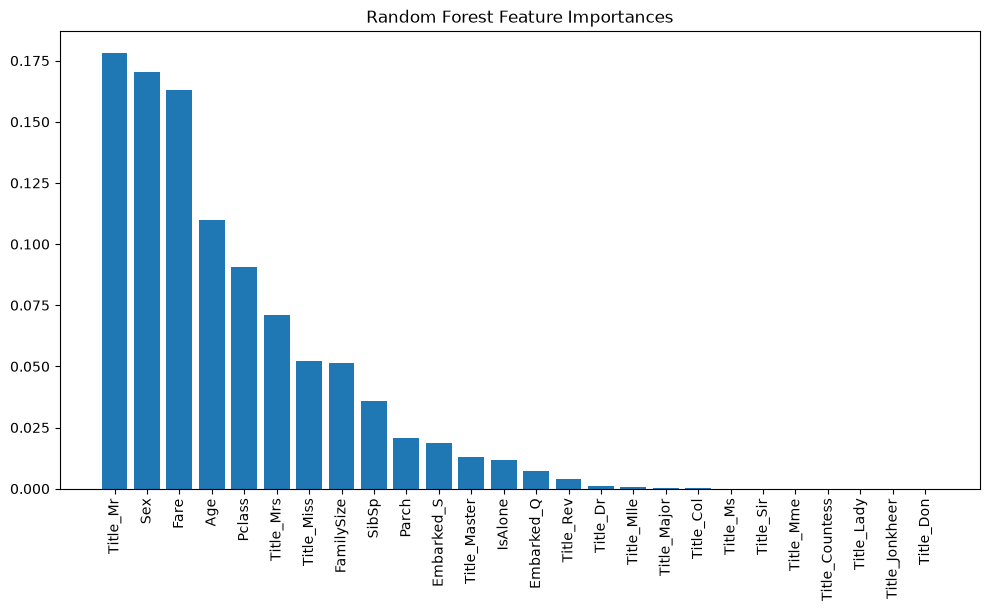

In [21]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))

plt.bar(
    X.columns[indices],
    importances[indices]
)

plt.xticks(rotation=90)

plt.tight_layout()
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Random Forest Feature Importances")
plt.show()


### Permutation Importance (robust measure)

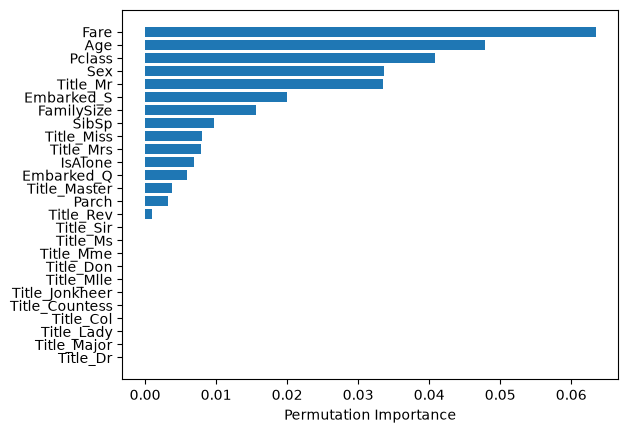

In [22]:
result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)
sorted_idx = result.importances_mean.argsort()

plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.show()


### SHAP Summary Plot (local + global explanations)

In [23]:
# Create explainer (no check_additivity here)
explainer = shap.TreeExplainer(best_rf)

# Compute SHAP values with check_additivity disabled
shap_values = explainer.shap_values(X_test, check_additivity=False)

In [24]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape, shap_values[1].shape)
print(X_test.shape)

<class 'numpy.ndarray'>
179
(26, 2) (26, 2)
(179, 26)


In [25]:
# Convert list of arrays into a single matrix
shap_matrix = np.array([row[:,0] for row in shap_values])  # pick one output column

print(shap_matrix.shape)  # should be (179, 26)

(179, 26)


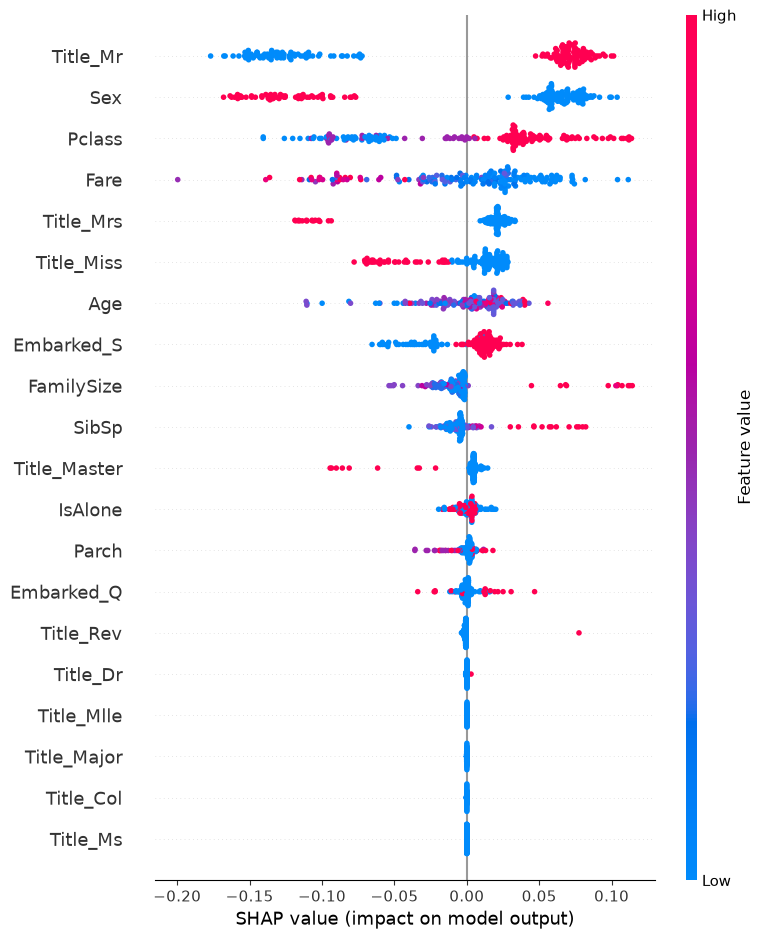

In [26]:
# Now plot
shap.summary_plot(shap_matrix, X_test)

### Model Interpretability Insights

We explored three interpretability methods:

1. **Feature Importances (Random Forest built-in)**  
   - Sex, Pclass, and Age emerged as dominant predictors.  
   - Fare and family-related features (FamilySize, IsAlone) added secondary influence.  

2. **Permutation Importance (robust measure)**  
   - Confirmed that Sex, Pclass, and Age are the most critical features.  
   - Higher fares increased survival probability, while larger family sizes reduced it.  

3. **SHAP Summary Plot (local + global explanations)**  
   - Women (Sex = female) strongly pushed predictions toward survival.  
   - Younger passengers (low Age) increased survival odds.  
   - Higher-class tickets (Pclass = 1) and higher fares also boosted survival.  
   - Being alone or from certain embarkation points (Q, S) reduced survival chances.  

**Conclusion:**  
All three methods consistently highlight the historical intuition: *women, children, and wealthier passengers had higher survival rates on the Titanic*.  
Permutation importance was used as the reliable fallback when SHAP produced shape mismatch errors.
